<img src="../../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../../images/Konstanz_Logo.svg" width="200" /> <img src="../../images/KIT_Logo.png" width="200" />

# Classification with Neural Networks

The goal of this notebook is to build a model that predicts **whether or not a
student will be admitted to university**, based on a handful of features from
their application — test scores, grades, the strength of their recommendation
letters, and so on.

We start by looking at what a neural network is made of, then zoom all the way in on a *single* neuron to see exactly what happens to a number as it flows through the network, and only then build and train our own model.

---

## Contents

1. [What we want to predict](#task)
2. [What is a neural network?](#network)
3. [The data](#data)
4. [Inside a single neuron](#neuron)
5. [The output neuron](#output)
6. [Preparing the data](#prepare)
7. [Building the network](#build)
8. [Training the network](#train)
9. [Evaluation](#evaluation)

<a id="task"></a>
## 1. What we want to predict

Every row in our dataset is one applicant, described by seven **features**:

| Feature | Meaning | Range |
|---|---|---|
| **TOEFL Score** | Score in the *Test of English as a Foreign Language* | 0 – 120 |
| **University Rating** | Rating of the applicant's undergraduate university | 1 – 5 |
| **Research** | Whether the applicant has research experience | 0 = no, 1 = yes |
| **GRE Score** | Score in the *Graduate Record Examination* | 260 – 340 |
| **CGPA** | Cumulative Grade Point Average of the undergraduate degree | 0 – 10 |
| **SOP** | Strength of the *Statement of Purpose* | 1 – 5 |
| **LOR** | Strength of the *Letter of Recommendation* | 1 – 5 |

And one **target variable** — the thing we want to predict:

| Target | Meaning |
|---|---|
| **Admitted** | `True` if the applicant was admitted, `False` otherwise |

Seven numbers go in, one `True`/`False` decision comes out. That is a **binary
classification** problem.

<a id="network"></a>
## 2. What is a neural network?

The model we will use for this prediction is a so-called **neural network**. The
figure below shows what it is made of: an **input layer**, two **hidden layers**,
and an **output layer**.

On the left you can see all the input features from our dataset — one neuron per
feature. On the right there is a single output neuron: **Admitted (True / False)**.

![Neural network architecture](../../images/nn_architecture.svg)

Every neuron is connected to every neuron in the next layer. Over the course of
this notebook we will learn in detail how it is possible that numerical values are
entered on the left, flow through the network, and a prediction is then produced
on the right.

<a id="data"></a>
## 3. The data

*Data source: [https://www.kaggle.com/datasets/mohansacharya/graduate-admissions](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)*

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Graduate_Admissions.csv")
df.head()

,TOEFL Score,University Rating,Research,GRE Score,CGPA,SOP,LOR,Admitted
0,118,4,1,337,9.65,4.5,4.5,True
1,107,4,1,324,8.87,4.0,4.5,True
2,104,3,1,316,8.00,3.0,3.5,True
3,110,3,1,322,8.67,3.5,2.5,True
4,103,2,0,314,8.21,2.0,3.0,False


In [3]:
print("Rows:    ", len(df))
print("Columns: ", list(df.columns))
print("Missing: ", df.isna().sum().sum())

Rows:     500
Columns:  ['TOEFL Score', 'University Rating', 'Research', 'GRE Score', 'CGPA', 'SOP', 'LOR', 'Admitted']
Missing:  0


`describe()` gives a quick statistical summary of every column. It is worth a
close look here — notice how different the scales are. `GRE Score` runs in the
300s while `Research` is only ever 0 or 1. We will come back to this in
[section 6](#prepare).

In [4]:
df.describe().round(2)

,TOEFL Score,University Rating,Research,GRE Score,CGPA,SOP,LOR
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,107.19,3.11,0.56,316.47,8.58,3.37,3.48
std,6.08,1.14,0.50,11.30,0.60,0.99,0.93
min,92.00,1.00,0.00,290.00,6.80,1.00,1.00
25%,103.00,2.00,0.00,308.00,8.13,2.50,3.00
50%,107.00,3.00,1.00,317.00,8.56,3.50,3.50
75%,112.00,4.00,1.00,325.00,9.04,4.00,4.00
max,120.00,5.00,1.00,340.00,9.92,5.00,5.00


### 3.1 How are the labels distributed?

Before training anything, check the balance of the target variable. This tells us
what a *trivial* model would score — one that ignores every feature and always
guesses the more common class.

In [5]:
label_shares = df["Admitted"].value_counts(normalize=True)
label_shares

,proportion
Admitted,
True,0.574
False,0.426


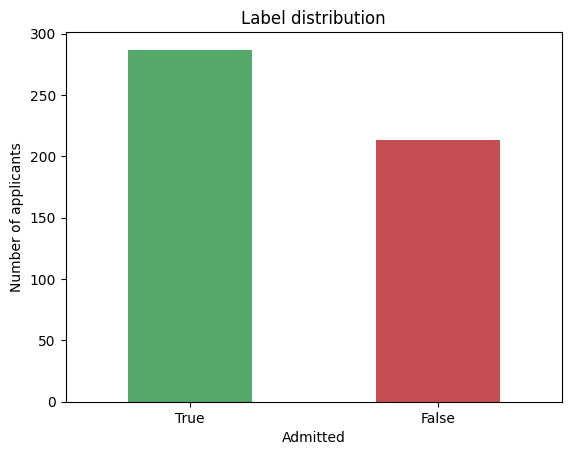

In [6]:
df["Admitted"].value_counts().plot(kind="bar", rot=0, color=["#55a868", "#c44e52"])
plt.title("Label distribution")
plt.ylabel("Number of applicants")
plt.show()

The classes are reasonably balanced, so always guessing the majority class lands
at roughly 57%. **That is the number our network has to beat.** An accuracy of 60%
would be a poor result, not a good one.

In [7]:
baseline_accuracy = label_shares.max()
print(f"Baseline (always predict the majority class): {baseline_accuracy:.1%}")

Baseline (always predict the majority class): 57.4%


<a id="neuron"></a>
## 4. Inside a single neuron

Now let us zoom into one neuron to have a closer look at what actually happens
when data is forwarded through the network.

The figure below shows the input neurons on the left and **one single neuron** from
the first hidden layer. Each connection carries a **weight** (w₁, w₂, …). The
neuron multiplies every incoming value by the weight of its connection, adds all
of those products together, adds a **bias** `b`, and pushes the result through an
**activation function** — here **ReLU**.

![A single hidden neuron](../../images/nn_hidden_neuron.svg)

These weights and biases are the **parameters of the model**. They start out as
random numbers and are gradually adjusted during training, so that in the end the
network produces accurate predictions. Everything a neural network "knows" lives
in those numbers.

### 4.1 The ReLU activation function

We will not go into much detail here, but the short version: without an activation
function, stacking layers would be pointless — a chain of multiplications and
additions collapses into a single one, and the network could only ever learn
straight lines. The activation function bends that line, which is what lets the
network capture more complicated patterns.

**ReLU** (*Rectified Linear Unit*) is the standard choice for hidden layers because
it is extremely cheap to compute — it either passes a value through unchanged or
replaces it with zero — and it trains reliably in deep networks, where older
activation functions tend to stall.

![The ReLU function](../../images/nn_relu.svg)

Even though ReLU is the standard, it is worth keeping in mind that it is not the
only possibility. Other options are:

**Leaky ReLU** repairs ReLU's one real weakness. A ReLU neuron that only ever
receives negative input returns zero every single time, and a neuron stuck at zero
stops learning altogether — a *dead neuron*. Leaky ReLU lets a small fraction of the
negative values through instead of flattening them completely.

![The Leaky ReLU function](../../images/nn_leaky_relu.svg)

**GELU** is a smoothed version of the same idea. Instead of a hard corner at zero the curve bends gradually, and
dips slightly below zero for small negative inputs.

![The GELU function](../../images/nn_gelu.svg)

**Tanh** predates ReLU and squashes every input into the range between −1 and +1.
That bounded output is also its problem: for inputs beyond roughly ±2 the curve is
almost flat, so the signal that drives learning very nearly disappears. This is a
large part of why ReLU replaced it in hidden layers.

![The tanh function](../../images/nn_tanh.svg)

> If you want to dig deeper, the Wikipedia article
> [Activation function](https://en.wikipedia.org/wiki/Activation_function)
> is a good starting point.

### 4.2 One neuron in code

Let us do exactly what the figure shows, with the first applicant from our dataset
and a set of made-up weights.

In [8]:
# The seven feature values of the first applicant
x = df.drop(columns="Admitted").iloc[0].to_numpy()
feature_names = df.drop(columns="Admitted").columns

# Made-up weights and bias -- in a real network these are learned during training
w = np.array([0.02, 0.05, 0.10, 0.01, 0.30, 0.04, 0.06])
b = -8.0

for name, value, weight in zip(feature_names, x, w):
    print(f"{name:<18} {value:>7}  x  {weight:>5}  =  {value * weight:>7.3f}")

TOEFL Score          118.0  x   0.02  =    2.360
University Rating      4.0  x   0.05  =    0.200
Research               1.0  x    0.1  =    0.100
GRE Score            337.0  x   0.01  =    3.370
CGPA                  9.65  x    0.3  =    2.895
SOP                    4.5  x   0.04  =    0.180
LOR                    4.5  x   0.06  =    0.270


In [9]:
def relu(z):
    return np.maximum(0, z)

z = np.dot(x, w) + b     # sum of all products, plus the bias
a = relu(z)

print(f"z = sum(x * w) + b = {z:.3f}")
print(f"a = ReLU(z)        = {a:.3f}")

z = sum(x * w) + b = 1.375
a = ReLU(z)        = 1.375


That single number `a` is the output of this one neuron. It is now passed on to
every neuron of the next layer, where exactly the same thing happens again — with
different weights.

<a id="output"></a>
## 5. The output neuron

What we just did by hand happens in **every** neuron of the network. The data flows
layer by layer from left to right until the output neuron is reached.

The figure below shows that last step. It looks almost identical: incoming values,
weights, a sum, a bias. The one difference is the activation function — the output
neuron uses a **sigmoid**, which forces the result into the range between 0 and 1.

![The output neuron](../../images/nn_output_neuron.svg)

![The sigmoid function](../../images/nn_sigmoid.svg)

### 5.1 From a number to a decision

The point of squeezing the output between 0 and 1 is that the result can then be
read as a **probability**: a value of 0.65 means the network estimates a 65% chance
that the label is `True`.

To turn that probability into an actual decision, a **threshold** is applied —
conventionally **0.5**, i.e. 50%:

- probability **≥ 0.5** → prediction is **`True`** (admitted)
- probability **< 0.5** → prediction is **`False`** (not admitted)

The code below shows an example.

In [10]:
# Imagine these are the outputs of the last hidden layer.
# Two of them are exactly 0 -- those neurons were switched off by their ReLU.
a_hidden = np.array([1.375, 0.0, 2.1, 0.8, 1.9, 0.0, 3.2])

w_out = np.array([0.4, 0.3, -0.2, 0.5, 0.6, 0.1, 0.3])
b_out = -2.0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_out = np.dot(a_hidden, w_out) + b_out
probability = sigmoid(z_out)

print(f"z           = {z_out:.3f}")
print(f"probability = {probability:.3f}   ->   {probability:.1%}")
print(f"threshold   = 0.5")
print(f"prediction  = {probability >= 0.5}")

z           = 0.630
probability = 0.652   ->   65.2%
threshold   = 0.5
prediction  = True


The network estimates a 65% chance of admission, which is above the 0.5 threshold —
so in this example the prediction would be interpreted as **`True`**.

That is the whole forward pass. Everything that remains is finding *good* values
for all those weights and biases, which is what training does.

<a id="prepare"></a>
## 6. Preparing the data

### 6.1 Splitting into training and test data

We hold back 20% of the applicants to measure performance on data the network has
never seen. `stratify=y` keeps the label proportions identical in both parts.

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Admitted")
y = df["Admitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")

Training rows: 400
Test rows:     100


### 6.2 Scaling the features

Remember the wildly different ranges we saw in `describe()`: `GRE Score` sits
around 320, `CGPA` around 8.6, and `Research` is 0 or 1.

That is a problem, because the network multiplies every feature by a weight and
adds the results. A feature measured in hundreds contributes far larger numbers
than one measured in single digits — not because it matters more, but purely
because of its unit. Training becomes slow and unstable.

**Standardisation** fixes this by rescaling every column to a mean of 0 and a
standard deviation of 1, putting all features on comparable footing.

> The scaler is fitted on the **training data only**. If it saw the test set, the
> test data would influence our preprocessing and the final score would be
> optimistic.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train),
                              columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),
                             columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().round(2)

,TOEFL Score,University Rating,Research,GRE Score,CGPA,SOP,LOR
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.55,-1.86,-1.14,-2.33,-2.95,-2.41,-2.18
25%,-0.72,-0.99,-1.14,-0.75,-0.72,-0.90,-0.54
50%,-0.05,-0.12,0.88,0.04,0.00,0.12,0.00
75%,0.78,0.75,0.88,0.74,0.76,0.62,0.55
max,2.11,1.62,0.88,2.05,2.21,1.64,1.64


Every column now has a mean of 0 and a standard deviation of 1.

<a id="build"></a>
## 7. Building the network

Now we build exactly the architecture from [section 2](#network): seven inputs, two
hidden layers with ReLU, and one output neuron with sigmoid.

Two more things have to be specified before the network can be trained:

**The loss function** measures how wrong the network's predictions are — it turns
"the answer should have been `True` but you said 0.3" into a single number. For
binary classification this is **binary cross-entropy**, which punishes confident
wrong answers much harder than hesitant ones.
([Cross-entropy on Wikipedia](https://en.wikipedia.org/wiki/Cross-entropy))

**The optimizer** is the procedure that adjusts the weights and biases to make that
loss smaller. We use **Adam**, a well-behaved default that adapts how big a step it
takes for each parameter.
([Adam on Wikipedia](https://en.wikipedia.org/wiki/Stochastic_gradient_descent#Adam))

Between them, those two are what learning actually *is*. The loss assigns an error
to every possible setting of the weights and biases; the optimizer starts from the
random values the network was handed and repeatedly takes a step in whichever
direction makes that error smaller. Repeat often enough and it walks downhill into a
setting that predicts well.

![Gradient descent](../../images/ml_gradient_descent.svg)

The figure shows a single parameter, because that is all that fits on a page. The
network we are about to build has **120** of them — the `model.summary()` below
counts them — so the real descent happens in 120 dimensions at once. Each individual
step, though, is exactly what the picture shows.

In [66]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Input(shape=[7]),                        # Input Layer  -- 7 features
    layers.Dense(units=7, activation="relu"),       # Hidden Layer 1
    layers.Dense(units=7, activation="relu"),       # Hidden Layer 2
    layers.Dense(units=1, activation="sigmoid"),    # Output Layer -- 1 probability
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

The `Param #` column in the summary counts exactly the weights and biases we talked
about in [section 4](#neuron) — those are the numbers training will optimise.

<a id="train"></a>
## 8. Training the network

### 8.1 Batch size

The network does not look at all 400 training rows at once. It works through them
in small chunks called **batches**. For each batch it makes predictions, measures
the loss, and updates its weights once.

![Splitting the data into batches](../../images/nn_batches.svg)

As a starting point it is common to pick a batch size that is a **power of two**
(16, 32, 64, 128 …). We use **32**.

### 8.2 Epochs

One **epoch** means the network has seen the entire training set once. Training for
several epochs lets it refine the same weights again and again.

Too few epochs and the network has not learned enough; too many and it starts
memorising the training data instead of generalising. There are proper methods for
finding a good number automatically — **early stopping** watches performance on a
validation set and halts once it stops improving
([early stopping on Wikipedia](https://en.wikipedia.org/wiki/Early_stopping)).

For a small educational example like ours, trial and error is perfectly fine, and
**100 epochs** gives good results here.

In [67]:
history = model.fit(X_train_scaled, y_train,
                    batch_size=32,
                    epochs=100,
                    verbose=1)      # verbose=1 prints a line per epoch

print("Training finished.")
print(f"Loss     after 100 epochs: {history.history['loss'][-1]:.4f}")

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7675 - loss: 0.6261  
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.5930 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8175 - loss: 0.5612 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8250 - loss: 0.5306 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8350 - loss: 0.5004 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8375 - loss: 0.4707 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8425 - loss: 0.4449 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8400 - loss: 0.4213 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8450 - loss: 0.4009 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8425 - loss: 0.3844 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8525 - loss: 0.3695 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Plotting the loss over time shows whether the training actually converged. A curve
that has flattened out means more epochs would not help much.

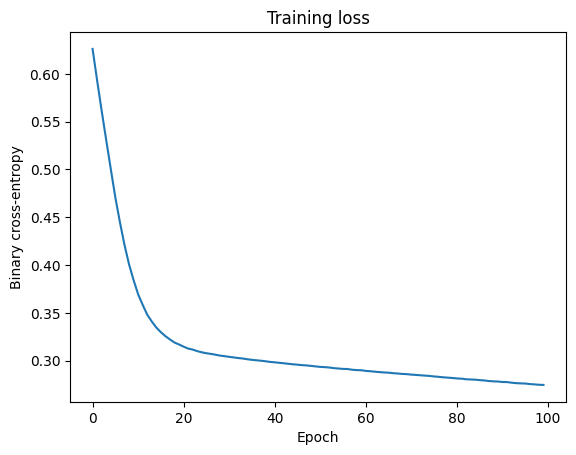

In [68]:
plt.plot(history.history["loss"])
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.show()

<a id="evaluation"></a>
## 9. Evaluation

The network outputs a probability for every applicant in the test set. Applying the
0.5 threshold from [section 5.1](#output) turns those probabilities into `True`/`False`
predictions.

In [69]:
y_probability = model.predict(X_test_scaled, verbose=0).ravel()
y_predict = y_probability >= 0.5

pd.DataFrame({
    "probability": y_probability[:10].round(3),
    "prediction": y_predict[:10],
    "actually admitted": y_test.to_numpy()[:10],
})

,probability,prediction,actually admitted
0,0.117,False,False
1,0.902,True,False
2,0.996,True,True
3,0.903,True,True
4,0.243,False,True
5,0.956,True,True
6,0.094,False,False
7,0.031,False,False
8,0.982,True,True
9,0.061,False,False


In [70]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_predict)

print(f"Accuracy: {accuracy:.1%}")
print(f"Baseline: {baseline_accuracy:.1%}")
print(f"Gain:     {accuracy - baseline_accuracy:+.1%}")

Accuracy: 87.0%
Baseline: 57.4%
Gain:     +29.6%


A single accuracy figure still hides *how* the network is wrong. The confusion
matrix breaks the same predictions down by class: the diagonal holds the correct
ones, everything off it is a mistake — the top right are admitted applicants we
missed, the bottom left are rejections we read as admissions.

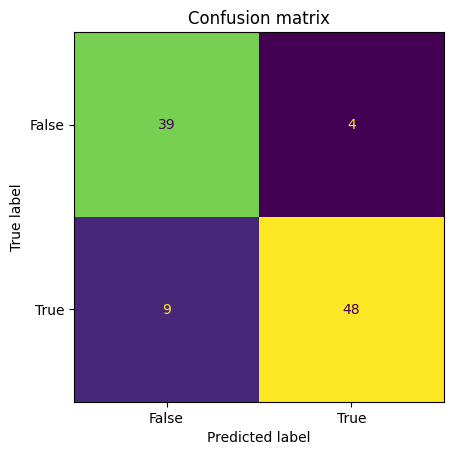

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_predict, colorbar=False)
plt.title("Confusion matrix")
plt.show()